In [1]:
import pandas as pd
import numpy as np
import scipy

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load the data with proper headers
df = pd.read_csv('Releasees_Under_Community_Supervision__Beginning_2008_20260421.csv')
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
print("\nData types:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head())

# Identify column types
numerical_cols = ['Age']  # Age is the only truly numerical column
# Note: Supervision Level contains 'PENDING' and NaN, so we'll treat it as categorical rather than ordinal
categorical_cols = ['Region of Supervision', 'County of Residence', 'Supervision Level', 'Gender', 'Crime', 'Race/Ethnicity', 'Snapshot Year']

print(f"\nNumerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Step 1: Handle missing values
numerical_imputer = SimpleImputer(strategy='mean')
categorical_imputer = SimpleImputer(strategy='most_frequent')

df[numerical_cols] = numerical_imputer.fit_transform(df[numerical_cols])
df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])

/tmp/ipykernel_54647/725964309.py:11: DtypeWarning: Columns (0: Supervision Level) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Releasees_Under_Community_Supervision__Beginning_2008_20260421.csv')


Dataset shape: (604852, 8)
Columns: ['Snapshot Year', 'Region of Supervision', 'County of Residence', 'Supervision Level', 'Gender', 'Age', 'Crime', 'Race/Ethnicity']

Data types:
Snapshot Year              int64
Region of Supervision        str
County of Residence          str
Supervision Level            str
Gender                       str
Age                      float64
Crime                        str
Race/Ethnicity               str
dtype: object

First few rows:
   Snapshot Year Region of Supervision County of Residence Supervision Level  \
0           2019         HUDSON VALLEY              ALBANY           LEVEL 4   
1           2019         HUDSON VALLEY              ALBANY           LEVEL 3   
2           2019         HUDSON VALLEY              ALBANY           LEVEL 3   
3           2019         HUDSON VALLEY              ALBANY           LEVEL 4   
4           2019         HUDSON VALLEY              ALBANY           LEVEL 2   

   Gender   Age            Crime Race/Ethnic

In [2]:
# Step 2: Encode categorical variables using ordinal encoding
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoded_cats = ordinal_encoder.fit_transform(df[categorical_cols])

# Combine all features (numerical + encoded)
df_encoded = np.hstack([df[numerical_cols].values, encoded_cats])

print(f"\nEncoded dataset shape: {df_encoded.shape}")
print("Encoded columns: Ordinal encoding applied to categorical variables")




Encoded dataset shape: (604852, 8)
Encoded columns: Ordinal encoding applied to categorical variables


In [3]:
# Step 3: Standardize the data (crucial for PCA)
# Step 3: Standardize the data (crucial for PCA) - now handles sparse input
scaler = StandardScaler()  # with_mean=False for sparse matrices
df_scaled = scaler.fit_transform(df_encoded)  # Remains sparse

print("\nData preprocessing complete! df_scaled is ready for PCA.")
print(f"Final shape for PCA: {df_scaled.shape}")


Data preprocessing complete! df_scaled is ready for PCA.
Final shape for PCA: (604852, 8)


In [4]:
features = numerical_cols + categorical_cols
all_features = features

In [9]:
from sklearn.decomposition import PCA
pca = PCA(n_components=4)
scores = pca.fit_transform(df_scaled)  # Use the standardized sparse matrix
print("\nPCA completed! Explained variance ratio:", pca.explained_variance_ratio_)


PCA completed! Explained variance ratio: [0.19408784 0.16786428 0.13689085 0.12594716]


In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=all_features,
    columns=["PC1","PC2","PC3","PC4"]
)

loadings

,PC1,PC2,PC3,PC4
Age,0.279715,-0.425008,-0.165346,-0.184539
Region of Supervision,0.228147,0.410311,-0.471619,0.157830
County of Residence,0.347493,0.355760,-0.506057,0.044233
Supervision Level,0.577925,-0.248487,0.032144,0.032453
Gender,-0.144424,-0.158454,-0.126241,0.880926
Crime,0.063956,0.494415,0.551152,0.237723
Race/Ethnicity,0.341870,0.359468,0.273223,-0.159224
Snapshot Year,0.522624,-0.252846,0.314249,0.283073


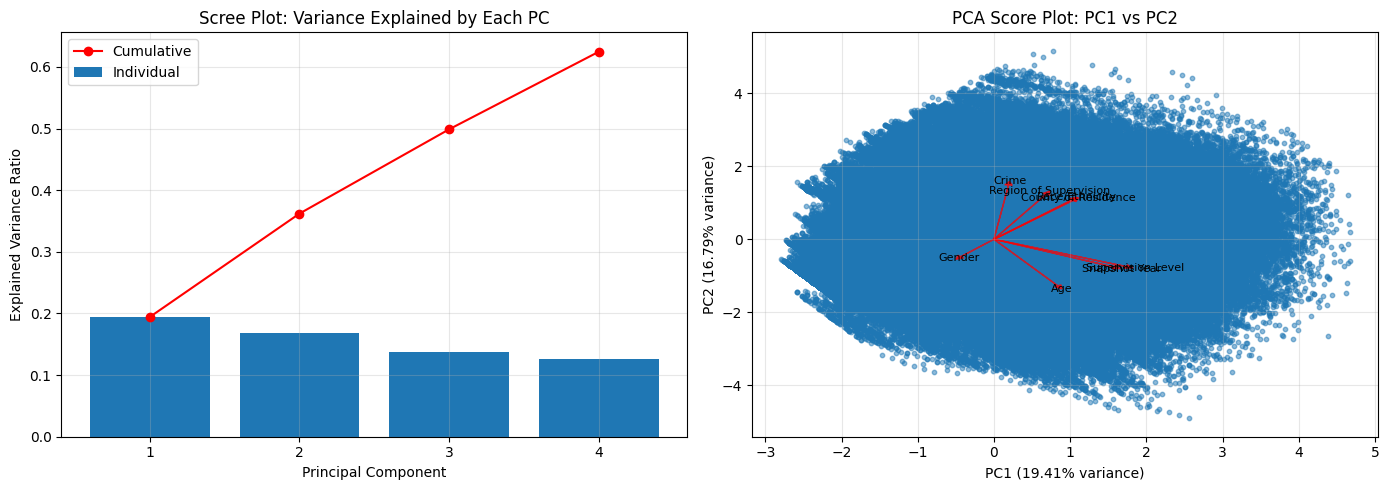

In [11]:
import matplotlib.pyplot as plt

# Create a figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scree plot (explained variance ratio)
axes[0].bar(range(1, 5), pca.explained_variance_ratio_)
axes[0].plot(range(1, 5), np.cumsum(pca.explained_variance_ratio_), 'ro-')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot: Variance Explained by Each PC')
axes[0].set_xticks(range(1, 5))
axes[0].legend(['Cumulative', 'Individual'])
axes[0].grid(True, alpha=0.3)

# Plot 2: Biplot (PC1 vs PC2)
axes[1].scatter(scores[:, 0], scores[:, 1], alpha=0.5, s=10)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
axes[1].set_title('PCA Score Plot: PC1 vs PC2')
axes[1].grid(True, alpha=0.3)

# Add loading vectors to the biplot
for i, feature in enumerate(all_features):
    axes[1].arrow(0, 0, loadings.iloc[i, 0]*3, loadings.iloc[i, 1]*3, 
                  head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.7)
    axes[1].text(loadings.iloc[i, 0]*3.2, loadings.iloc[i, 1]*3.2, feature, 
                 fontsize=8, ha='center', va='center')

plt.tight_layout()
plt.show()

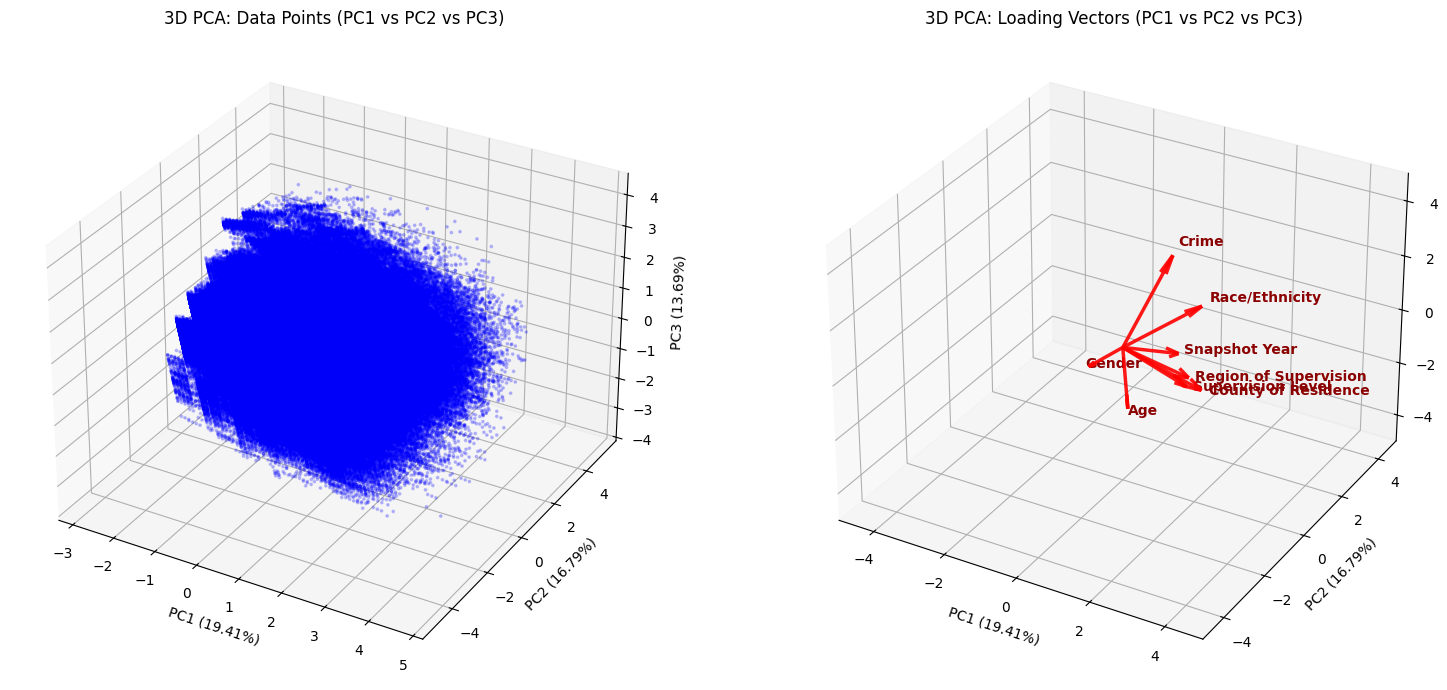

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create two separate 3D plots for clarity
fig = plt.figure(figsize=(16, 7))

# Plot 1: Data points only
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(scores[:, 0], scores[:, 1], scores[:, 2], alpha=0.2, s=3, c='blue')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax1.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%})')
ax1.set_title('3D PCA: Data Points (PC1 vs PC2 vs PC3)')

# Plot 2: Loading vectors only
ax2 = fig.add_subplot(122, projection='3d')
scale_factor = 4
for i, feature in enumerate(all_features):
    ax2.quiver(0, 0, 0, 
               loadings.iloc[i, 0]*scale_factor, 
               loadings.iloc[i, 1]*scale_factor, 
               loadings.iloc[i, 2]*scale_factor,
               color='red', alpha=0.9, arrow_length_ratio=0.2, linewidth=2.5)
    ax2.text(loadings.iloc[i, 0]*scale_factor*1.1, 
             loadings.iloc[i, 1]*scale_factor*1.1, 
             loadings.iloc[i, 2]*scale_factor*1.1, 
             feature, fontsize=10, weight='bold', color='darkred')

ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax2.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%})')
ax2.set_title('3D PCA: Loading Vectors (PC1 vs PC2 vs PC3)')
ax2.set_xlim([-5, 5])
ax2.set_ylim([-5, 5])
ax2.set_zlim([-5, 5])

plt.tight_layout()
plt.show()

In [16]:
# Print the actual loadings to see the numbers
print("\n=== Loading Values ===")
print(loadings)
print("\n=== Absolute Loadings (importance) ===")
print(loadings.abs())


=== Loading Values ===
                            PC1       PC2       PC3       PC4
Age                    0.279715 -0.425008 -0.165346 -0.184539
Region of Supervision  0.228147  0.410311 -0.471619  0.157830
County of Residence    0.347493  0.355760 -0.506057  0.044233
Supervision Level      0.577925 -0.248487  0.032144  0.032453
Gender                -0.144424 -0.158454 -0.126241  0.880926
Crime                  0.063956  0.494415  0.551152  0.237723
Race/Ethnicity         0.341870  0.359468  0.273223 -0.159224
Snapshot Year          0.522624 -0.252846  0.314249  0.283073

=== Absolute Loadings (importance) ===
                            PC1       PC2       PC3       PC4
Age                    0.279715  0.425008  0.165346  0.184539
Region of Supervision  0.228147  0.410311  0.471619  0.157830
County of Residence    0.347493  0.355760  0.506057  0.044233
Supervision Level      0.577925  0.248487  0.032144  0.032453
Gender                 0.144424  0.158454  0.126241  0.880926
Crime 

In [25]:
for i, col in enumerate(categorical_cols):
    print(f"\nMapping for '{col}':")
    for idx, category in enumerate(ordinal_encoder.categories_[i]):
        print(f"  {idx} -> {category}")


Mapping for 'Region of Supervision':
  0 -> BRONX
  1 -> BROOKLYN
  2 -> CENTRAL NY
  3 -> DOWNSTATE PVU
  4 -> DRUG TREATMENT PROGRAM
  5 -> HUDSON VALLEY
  6 -> MANHATTAN
  7 -> OUT OF STATE
  8 -> QUEENS-LI
  9 -> UPSTATE PVU
  10 -> WESTERN
  11 -> WILLARD

Mapping for 'County of Residence':
  0 -> ALBANY
  1 -> ALLEGANY
  2 -> BRONX
  3 -> BROOME
  4 -> CATTARAUGUS
  5 -> CAYUGA
  6 -> CHAUTAUQUA
  7 -> CHEMUNG
  8 -> CHENANGO
  9 -> CLINTON
  10 -> COLUMBIA
  11 -> CORTLAND
  12 -> DELAWARE
  13 -> DUTCHESS
  14 -> ERIE
  15 -> ESSEX
  16 -> FRANKLIN
  17 -> FULTON
  18 -> GENESEE
  19 -> GREENE
  20 -> HAMILTON
  21 -> HERKIMER
  22 -> JEFFERSON
  23 -> KINGS
  24 -> KINGS (BROOKLYN)
  25 -> LEWIS
  26 -> LIVINGSTON
  27 -> MADISON
  28 -> MONROE
  29 -> MONTGOMERY
  30 -> NASSAU
  31 -> NEW YORK
  32 -> NEW YORK (MANHATTAN)
  33 -> NIAGARA
  34 -> ONEIDA
  35 -> ONONDAGA
  36 -> ONTARIO
  37 -> ORANGE
  38 -> ORLEANS
  39 -> OSTEGO
  40 -> OSWEGO
  41 -> OTSEGO
  42 -> OUT OF 